In [4]:
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [5]:
# read in all the words
cwd = os.getcwd()
words = open(cwd + '/../' + 'names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
len(words)

32033

In [7]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [107]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%


torch.Size([182437, 3]) torch.Size([182437])
torch.Size([22781, 3]) torch.Size([22781])
torch.Size([22928, 3]) torch.Size([22928])


In [138]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01    # Set to small numbers to lower loss and squeeze logits to zero
b2 = torch.randn(vocab_size,                      generator=g) * 0       # I want no bias at the start

bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
# with the running mean and std, we do not need to compute mean/std for the batch normalization with all the training set
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


In [139]:
# x = torch.randn(1000, 10)
# w = torch.randn(10, 200) / 30**0.5
# y = x @ w
# print(x.mean(), x.std())
# print(y.mean(), y.std())
# plt.figure(figsize=(20,5))
# plt.subplot(121)
# plt.hist(x.view(-1).tolist(), 50, density=True);
# plt.subplot(122)
# plt.hist(y.view(-1).tolist(), 50, density=True);

# How do we scale w to preserve these distributions? Intuitively, if I multiply w by 5 (large number) the gaussian expand. 
# The opposite if I moltiplu for a small number -> divide by the square root of the the fan-in to GET Y STD of 1.0a

# NOW IT IS NOT NECESSARY ANYMORE BECAUSE OF BatchNormalization

In [140]:
hpreact.mean(0, keepdim=True).shape

torch.Size([1, 200])

In [141]:
hpreact.std(0, keepdim=True).shape

torch.Size([1, 200])

In [143]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation
    # Here we do not need the bias anymore since subtracting by bnmeani will get rid of the bias and b1 is basically useless

    # Batch Normalization -> this haas to be done only at the first iteration
    # ---------------------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    # ---------------------------------------------------------------------------
    
    # Non-linearity
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
        
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    #break

      0/ 200000: 3.3054
  10000/ 200000: 1.7978
  20000/ 200000: 1.9030
  30000/ 200000: 2.4623
  40000/ 200000: 2.4436
  50000/ 200000: 1.8843
  60000/ 200000: 2.4164
  70000/ 200000: 2.1734
  80000/ 200000: 1.7217
  90000/ 200000: 2.3225
 100000/ 200000: 2.2514
 110000/ 200000: 2.1481
 120000/ 200000: 1.9692
 130000/ 200000: 1.7992
 140000/ 200000: 2.2786
 150000/ 200000: 2.1926
 160000/ 200000: 1.9286
 170000/ 200000: 2.1592
 180000/ 200000: 2.5601
 190000/ 200000: 1.7961


In [110]:
#plt.figure(figsize=(20,10))
#plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

# White means True, black means False. The figure shows that many neurons are in the flat part of the tanh (dead neuron, vanishing gradient)
# Being in the flat part means that a modification to the input will stay in the flat part of the tanh and the loss won't change

# The fact that there are not entire columns of white is okeish, but too many white cells are typically bad
# This is due to the hpreact that is too extreme

In [111]:
# plt.hist(h.view(-1).tolist(), 50);

In [112]:
# plt.hist(hpreact.view(-1).tolist(), 50);

In [113]:
# Since in the first run we get loss 26.5 at the first iteration, it means that there are some problems in the initalization.

# In particular, I would expect to get a loss of 1/27.0 (uniform) probability at the first iteration.
# This means that the loss = -torch.tensor(1/27.0).log() = 3.2958
# This means that there is a problem

In [144]:
##  4-dimensional example of the issue
# logits = torch.tensor([1.0, 1.0, 1.0, 1.0])
## logits = torch.randn(4) * 100
# probs = torch.softmax(logits, dim=0)
# loss = -probs[2].log()
# logits, probs, loss 

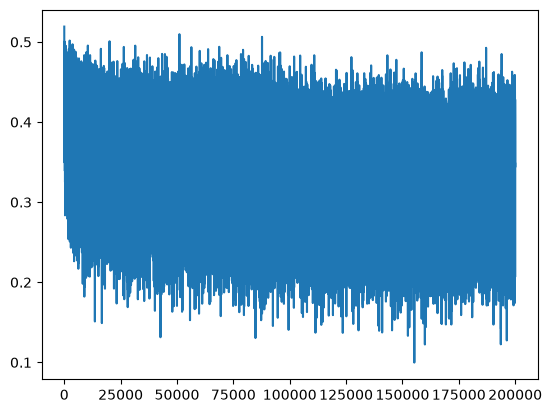

In [145]:
plt.plot(lossi)

In [146]:
## calibrate the batch norm at the end of training, computed on the entire training set and fixed for evaluation
# with torch.no_grad():
#    # pass the training set through
#    emb = C[Xtr]
#    embcat = emb.view(emb.shape[0], -1)
#    hpreact = embcat @ W1 + b1
    
#    # measure the mean/std over the entire training set
#    bnmean = hpreact.mean(0, keepdim=True)
#    bnstd = hpreact.std(0, keepdim=True)

In [147]:
@torch.no_grad() # decorator disables gradient tracking
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0649776458740234
val 2.125718355178833


In [25]:
#sample from the molde
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size

    while True:
        # forward pass
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

carmah.
ambrilli.
kimri.
rehtlinna.
sane.
mahnen.
deliah.
jaree.
corrisephanaiir.
kaleigh.
ham.
join.
quinton.
lilea.
jamilio.
jerry.
jarynix.
kael.
drudi.
emmedo.


In [149]:
# SUMMARY -------- (Pytorchifying)

In [208]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight =  torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5 
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps =  eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running "momentum update")
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)               # batch mean
            xvar = x.var(0, keepdim=True, unbiased=True)  # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xhat + self.beta

        # update buffer
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [209]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd))
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    #layers[-1].weight *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
         layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of params in total
for p in parameters:
    p.requires_grad = True

47551


In [210]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb) # loss function
    
    # backward pass
    for layer in layers:
        layer.out.retain_grad()    # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()
        
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
        
    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])
    
    if i >= 1000:
        break     # AFTER_DEBUG: would take out to run full optimization

      0/ 200000: 3.2695


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.97%
layer 5 (      Tanh): mean +0.01, std 0.64, saturated: 2.44%
layer 8 (      Tanh): mean +0.01, std 0.65, saturated: 2.12%
layer 11 (      Tanh): mean -0.00, std 0.65, saturated: 1.94%
layer 14 (      Tanh): mean +0.00, std 0.65, saturated: 2.00%


Text(0.5, 1.0, 'activation distribution')

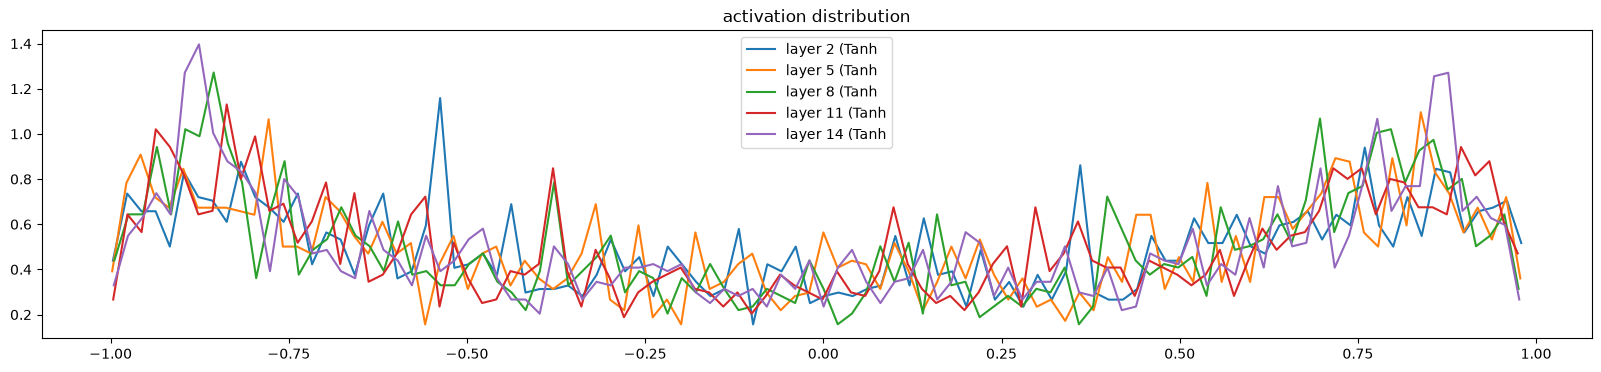

In [211]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 2.914916e-03
layer 5 (      Tanh): mean +0.000000, std 2.595491e-03
layer 8 (      Tanh): mean +0.000000, std 2.460824e-03
layer 11 (      Tanh): mean +0.000000, std 2.377664e-03
layer 14 (      Tanh): mean -0.000000, std 2.344118e-03


Text(0.5, 1.0, 'gradient distribution')

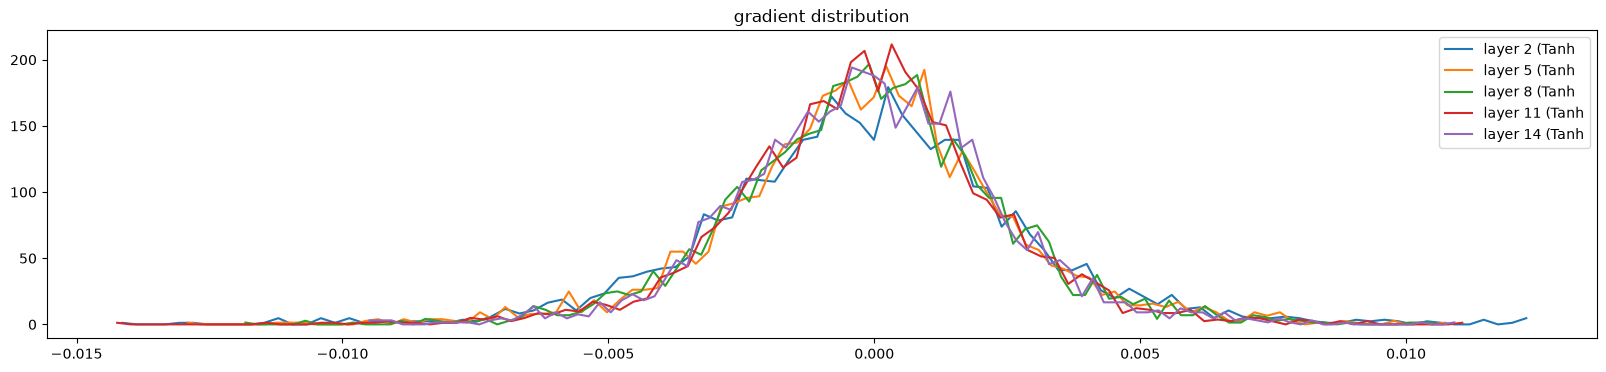

In [212]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 9.745297e-03 | grad:data ratio 9.931399e-03
weight  (30, 100) | mean +0.000035 | std 7.940262e-03 | grad:data ratio 2.574041e-02
weight (100, 100) | mean +0.000065 | std 5.732323e-03 | grad:data ratio 3.407917e-02
weight (100, 100) | mean -0.000081 | std 5.213742e-03 | grad:data ratio 3.113209e-02
weight (100, 100) | mean -0.000099 | std 5.114885e-03 | grad:data ratio 3.050855e-02
weight (100, 100) | mean -0.000010 | std 4.891557e-03 | grad:data ratio 2.899859e-02
weight  (100, 27) | mean +0.000039 | std 9.685139e-03 | grad:data ratio 5.815059e-02


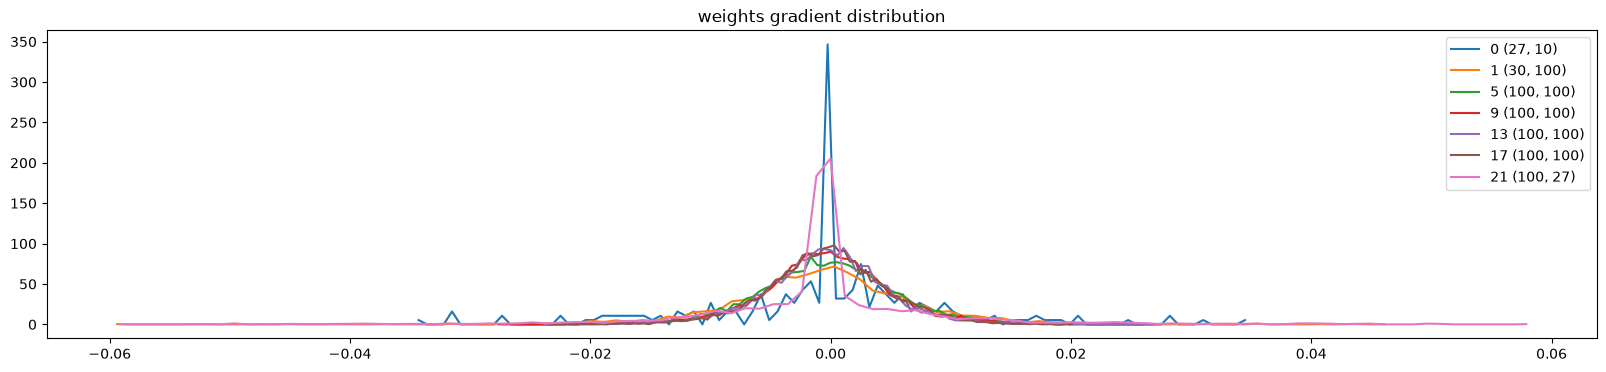

In [213]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

Text(0.5, 1.0, 'update to learning ratio')

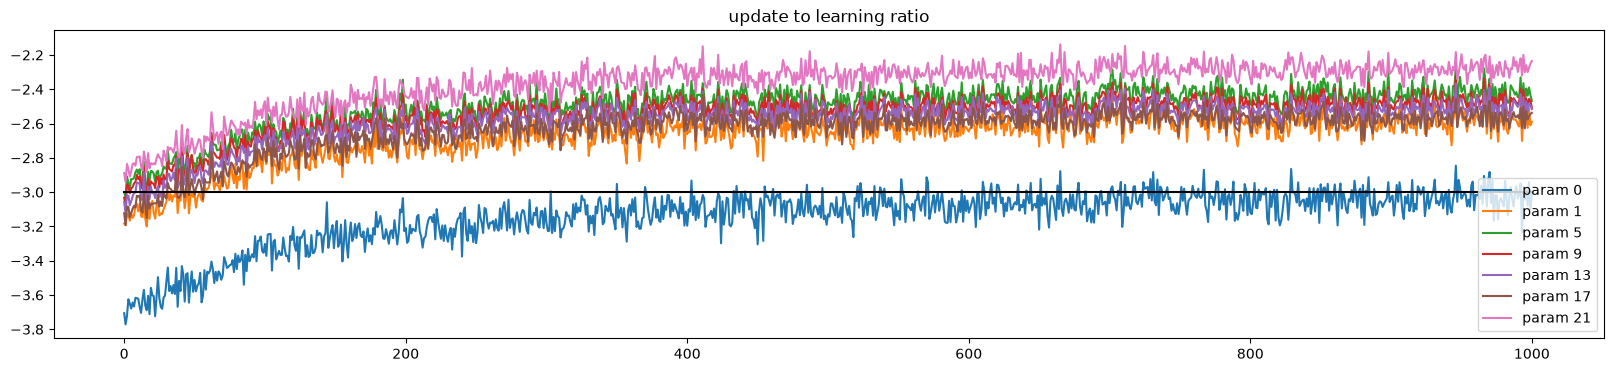

In [214]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);
plt.title('update to learning ratio')
# If above the black line -> lr is too high
# If below the black line -> lr is too low